In [32]:
nth_prime(400)

2741

deformed_h_list[0]: 1
n: 1 prec_bits: 100 elapsed: 0.08742709954579671
n: 2 prec_bits: 100 elapsed: 0.08847113053003947
n: 3 prec_bits: 100 elapsed: 0.08856998284657797
n: 4 prec_bits: 100 elapsed: 0.0887014349301656
n: 5 prec_bits: 100 elapsed: 0.08927151362101236
n: 6 prec_bits: 100 elapsed: 0.08930915196736654
n: 7 prec_bits: 100 elapsed: 0.08935005267461141
n: 8 prec_bits: 100 elapsed: 0.08939086596171061
n: 9 prec_bits: 100 elapsed: 0.08943055073420207
n: 10 prec_bits: 100 elapsed: 0.08947818279266358
n: 11 prec_bits: 100 elapsed: 0.08953871726989746
n: 12 prec_bits: 100 elapsed: 0.08961039781570435
n: 13 prec_bits: 100 elapsed: 0.08969123363494873
n: 14 prec_bits: 100 elapsed: 0.08979854981104533
n: 15 prec_bits: 100 elapsed: 0.08989694913228354
n: 16 prec_bits: 100 elapsed: 0.09001338084538778
n: 17 prec_bits: 100 elapsed: 0.09014803568522135
n: 18 prec_bits: 100 elapsed: 0.09029080073038737
n: 19 prec_bits: 100 elapsed: 0.09045981566111247
n: 20 prec_bits: 100 elapsed: 0.090631

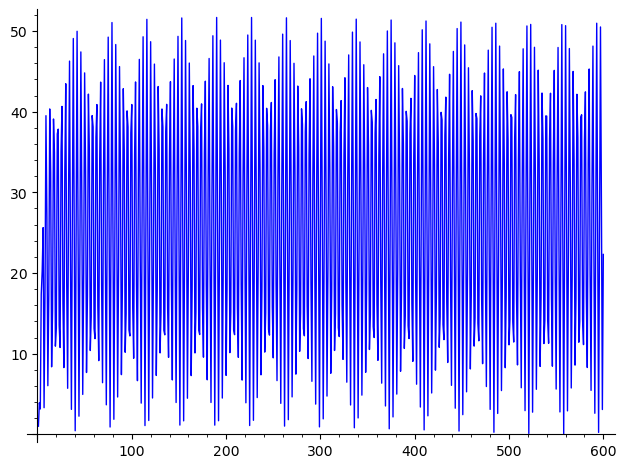

In [1]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()

# --- dynamic precision settings -------------------------------------------
# The all-roots problem loses on the order of ~1 bit of accuracy per unit n
# (the "precision wall"), and the smallest root -- the one tracked here -- is
# the most fragile.  So precision_bits is set PER n rather than once:
#     precision_bits = max(base_precision_bits, ceil(precision_slope * n)).
# base 100 reproduces the old fixed setting at small n; slope 1.0 tracks the
# wall and gives ample margin for the smallest root (which empirically was
# already fine at a flat 100 bits out to n=500).  If a stability spot-check at
# the largest n shows the smallest |root| drifting, raise precision_slope
# (e.g. to 1.5 or 2.0) and rerun.
base_precision_bits = 100
precision_slope     = 1.0
# --------------------------------------------------------------------------

x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

N_MAX = 600                                   # was 500; extend to test for the
                                               # predicted defect near n~490-500
                                               # and the next scale near n~917
D = delta_qexp(nth_prime(N_MAX) + 2)           # enough q-terms for 1000 primes
h_list=[1]+[D[nth_prime(k)] for k in range(1,N_MAX+1)]
j_list=j_sequence_from_h(h_list)
c=1
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
log_mins_list=[]
for n in range(1,N_MAX+1):
    precision_bits = max(base_precision_bits, ceil(precision_slope * n))
    CC = ComplexField(precision_bits)
    print("n:",n,"prec_bits:",precision_bits,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))
        log_mins_list.append((n,log(minn)))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()  

with open('/Users/barrybrent/data2/run19jun26no1.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 
with open('/Users/barrybrent/data2/run19jun26no2.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run19jun26no3.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run19jun26no4.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
    # stored on Zenodo at https://zenodo.org/records/20766198
with open('/Users/barrybrent/data2/run19jun26no5.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run19jun26no6.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) # https://zenodo.org/records/20766226
with open('/Users/barrybrent/data2/run19jun26no7.txt', 'wb') as wfile:
    pickle.dump(log_mins_list, wfile)


LOG MINIMUM MODULI


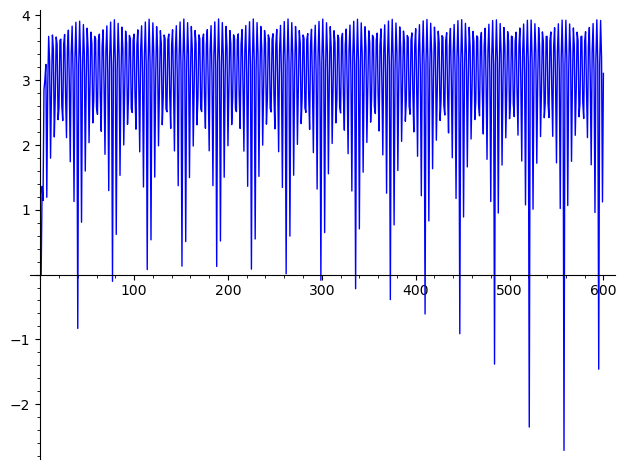

In [2]:
import pickle

with open('/Users/barrybrent/data2/run19jun26no7.txt', 'rb') as rfile:
    log_mins_list = pickle.load(rfile)

p = list_plot(log_mins_list, plotjoined=True, axes_labels=['', ''])
print("LOG MINIMUM MODULI")
p.show()  

Data range: n = 1 to 600
Number of data points: 600
Min modulus range: 0.066306 to 51.682877

SEGMENTATION  (for context; only the LAST segment is analyzed)
  Breakpoints detected (after merge): 0
  Segment 1: n = 1 to 600  (600 points)  range [0.07, 51.68]  <-- ANALYZED

FINAL SEGMENT METRICS  (n = 1 to 600, 600 points)

  [Detrending]
    linear-fit slope        : 0.002589
    residual std dev        : 14.981558
    residual / value scale  : 2.899e-01

  [Envelope]
    dynamic range (p90/p10) : 1.036
    monotonicity (|Spearman|): 0.246
    normalization applied   : False

  [Spectral baseline]
    AR(1) lag-1 autocorr rho: 0.0502
    frequency bins tested   : 297
    max credible period     : 200.0  (= n/3)

  [FFT peaks (period <= n/3), strongest first]
      Period        Power Integer(95)% thr Integer(99)% thr  Power/95%
        4.11    2.647e+07    1.180e+06    1.398e+06      22.43
        3.70    3.109e+05    1.160e+06    1.375e+06       0.27
        4.62    3.647e+04    1.200e

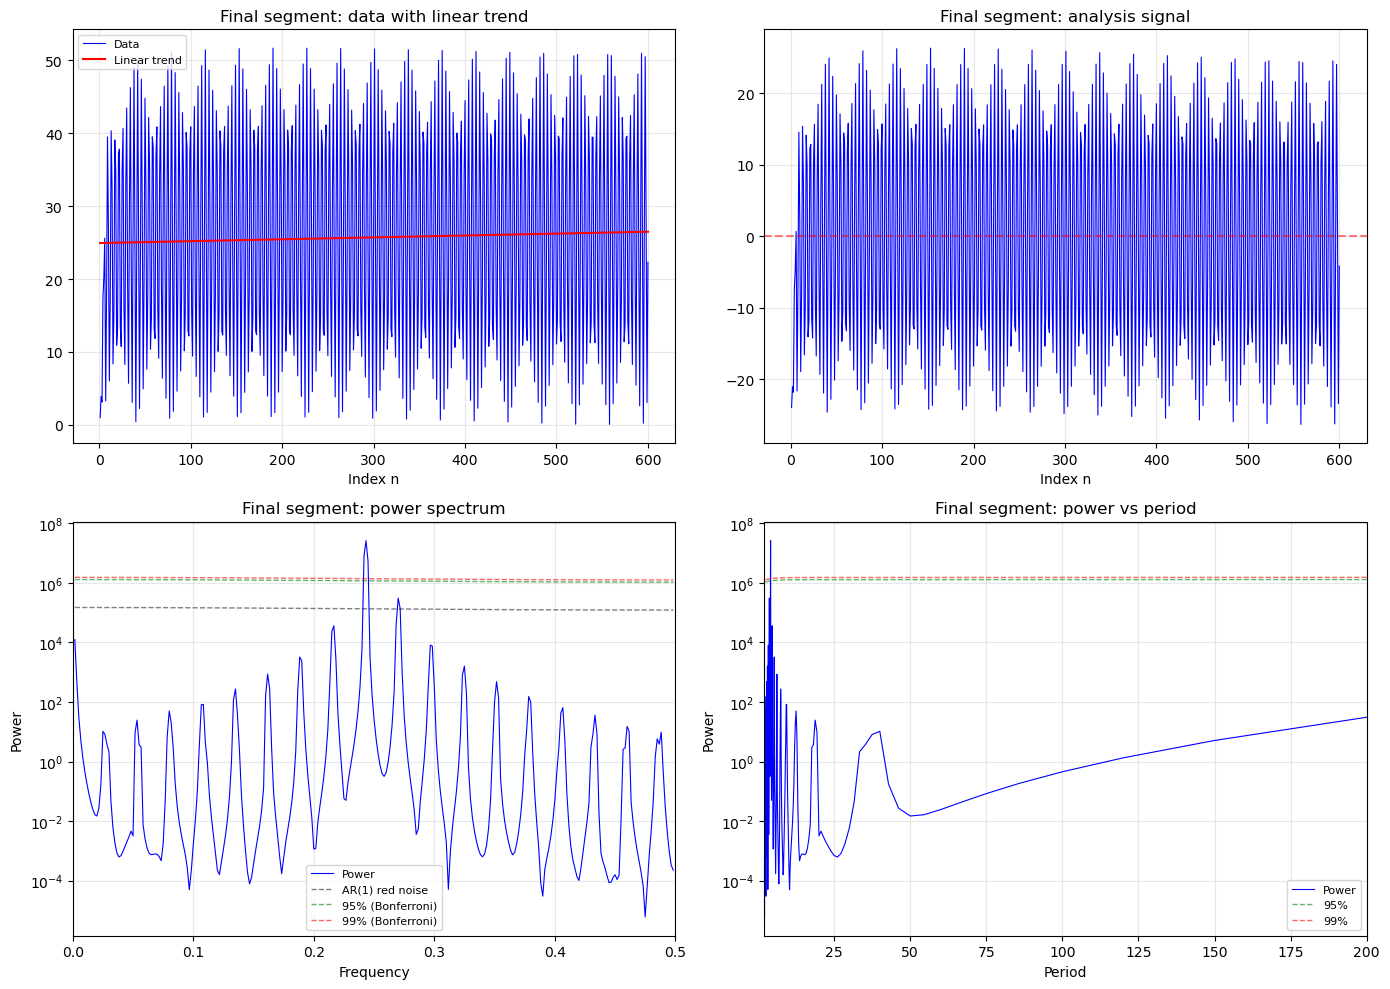


Analysis complete.


In [3]:
import pickle
with open('/Users/barrybrent/data2/run19jun26no5.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)
# SEGMENTED FOURIER ANALYSIS OF MINIMUM MODULI  (v11)
#
# DESIGN CHANGES RELATIVE TO v10:
#
#  1. LAST SEGMENT ONLY.  The oscillation phenomenon emerges as the index n
#     grows, so only the final segment (after the last structural breakpoint)
#     is analyzed.  Earlier segments are located, reported, and plotted for
#     context only ‚Äî they are not analyzed for periodicity.
#
#  2. NO VERDICTS.  The code does not output PERIODIC / NOT PERIODIC labels.
#     It reports the raw metrics and their scores, and leaves interpretation
#     to the reader.  The metrics are:
#       - linear-detrend slope and residual standard deviation
#       - envelope dynamic range and monotonicity (and whether normalization
#         was applied)
#       - AR(1) lag-1 autocorrelation (rho)
#       - FFT peak periods with their power and the Bonferroni-corrected
#         95% / 99% red-noise thresholds at the same frequency
#       - multi-scale ACF: each detected period, the scale at which it was
#         found, and its ACF strength, with the fundamental identified
#       - the white-noise ACF reference band (1.96 / sqrt(n)), so the ACF
#         strengths can be judged against what white noise would produce
#
#  3. VISUALIZATIONS restricted to the final segment.
#
# Segmentation (level-based ruptures Pelt with l2 cost, plus slope-merge
# cleanup) and the analysis machinery are carried over unchanged from v10.
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt
import ruptures as rpt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. BREAKPOINT DETECTION  (level-based, with slope-merge cleanup)
# ==============================================================================
# Used only to locate the final segment.  Detection is the ruptures Pelt
# algorithm with the l2 (mean-shift) cost on the data levels, followed by a
# slope-merge step that collapses adjacent segments of nearly equal slope
# (so an over-segmented linear ramp becomes one segment).

penalty_value = np.log(N) * np.var(minmoduli)
algo = rpt.Pelt(model="l2", min_size=max(20, N // 10)).fit(minmoduli)
breakpoints = algo.predict(pen=penalty_value)
seg_boundaries = [0] + breakpoints

_idx = np.arange(N)
_merged = True
while _merged and len(seg_boundaries) > 2:
    _merged = False
    slopes = []
    for i in range(len(seg_boundaries) - 1):
        s, e = seg_boundaries[i], seg_boundaries[i+1]
        slopes.append(np.polyfit(_idx[s:e], minmoduli[s:e], 1)[0])
    slope_scale = max(abs(max(slopes)), abs(min(slopes)), 1e-9)
    for i in range(len(slopes) - 1):
        if abs(slopes[i] - slopes[i+1]) < 0.15 * slope_scale:
            seg_boundaries.pop(i + 1)
            _merged = True
            break

n_segments = len(seg_boundaries) - 1

print(f"\n{'='*75}")
print(f"SEGMENTATION  (for context; only the LAST segment is analyzed)")
print(f"{'='*75}")
print(f"  Breakpoints detected (after merge): {n_segments - 1}")
for i in range(n_segments):
    start_idx = seg_boundaries[i]
    end_idx = seg_boundaries[i+1]
    si = indices[start_idx:end_idx]
    sv = minmoduli[start_idx:end_idx]
    tag = "  <-- ANALYZED" if i == n_segments - 1 else ""
    print(f"  Segment {i+1}: n = {int(si[0])} to {int(si[-1])}  "
          f"({end_idx - start_idx} points)  "
          f"range [{sv.min():.2f}, {sv.max():.2f}]{tag}")

# ==============================================================================
# 3. METRICS FOR THE FINAL SEGMENT
# ==============================================================================
last_start = seg_boundaries[-2]
last_end = seg_boundaries[-1]
seg_indices = indices[last_start:last_end]
seg_values = minmoduli[last_start:last_end]
n = len(seg_indices)

print(f"\n{'='*75}")
print(f"FINAL SEGMENT METRICS  (n = {int(seg_indices[0])} to {int(seg_indices[-1])}, "
      f"{n} points)")
print(f"{'='*75}")

metrics = {}  # collected for the visualization section

if n < 10:
    print(f"  Final segment too short ({n} points) for analysis.")
    metrics = None
else:
    max_credible_period = n / 3.0

    # --- Linear detrend ---
    coeffs = np.polyfit(seg_indices, seg_values, deg=1)
    trend = np.polyval(coeffs, seg_indices)
    detrended = seg_values - trend
    slope = coeffs[0]

    print(f"\n  [Detrending]")
    print(f"    linear-fit slope        : {slope:.6f}")
    print(f"    residual std dev        : {np.std(detrended):.6f}")

    value_scale = max(np.max(np.abs(seg_values)), 1e-30)
    resid_ratio = np.std(detrended) / value_scale
    print(f"    residual / value scale  : {resid_ratio:.3e}")

    # --- Envelope normalization ---
    abs_det = np.abs(detrended)
    env_win = max(5, min(n // 10, n // 3))
    if env_win % 2 == 0:
        env_win += 1
    env_win = min(env_win, n - 1)
    if env_win % 2 == 0:
        env_win -= 1
    if env_win < 5:
        env_win = 5

    envelope = None
    if env_win >= n:
        envelope_applied = False
        analysis_signal = detrended
        envelope_ratio = float('nan')
        env_monotonicity = float('nan')
    else:
        envelope = signal.savgol_filter(abs_det, window_length=env_win,
                                        polyorder=min(2, env_win - 1))
        env_floor = np.percentile(abs_det[abs_det > 0], 5) if np.any(abs_det > 0) else 1.0
        envelope = np.maximum(envelope, env_floor)
        env_p10 = np.percentile(envelope, 10)
        env_p90 = np.percentile(envelope, 90)
        envelope_ratio = env_p90 / env_p10 if env_p10 > 0 else 1.0
        sp = stats.spearmanr(np.arange(n), envelope).correlation
        env_monotonicity = abs(sp) if sp == sp else 0.0
        if envelope_ratio > 3.0 and env_monotonicity > 0.6:
            analysis_signal = detrended / envelope
            envelope_applied = True
        else:
            analysis_signal = detrended
            envelope_applied = False

    print(f"\n  [Envelope]")
    print(f"    dynamic range (p90/p10) : {envelope_ratio:.3f}")
    print(f"    monotonicity (|Spearman|): {env_monotonicity:.3f}")
    print(f"    normalization applied   : {envelope_applied}")

    # --- Windowed FFT ---
    window = np.hanning(n)
    windowed = analysis_signal * window
    window_power_correction = n / np.sum(window**2)
    fft_result = np.fft.fft(windowed)
    fft_freqs = np.fft.fftfreq(n, d=1.0)
    power_spectrum = np.abs(fft_result)**2 * window_power_correction
    pos = fft_freqs > 0
    frequencies = fft_freqs[pos]
    power = power_spectrum[pos]
    periods = 1.0 / frequencies

    # --- AR(1) red-noise baseline + Bonferroni-corrected thresholds ---
    rho = np.corrcoef(analysis_signal[:-1], analysis_signal[1:])[0, 1]
    variance = np.var(analysis_signal)
    ar1_power = (variance * (1 - rho**2)) / (
        1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
    )
    ar1_power *= np.mean(power) / np.mean(ar1_power)

    credible_mask = periods <= max_credible_period
    n_tests = int(np.sum(credible_mask))
    if n_tests < 1:
        n_tests = 1
    chi2_95 = stats.chi2.ppf(1.0 - (0.05 / n_tests), df=2) / 2.0
    chi2_99 = stats.chi2.ppf(1.0 - (0.01 / n_tests), df=2) / 2.0
    conf_95 = ar1_power * chi2_95
    conf_99 = ar1_power * chi2_99

    print(f"\n  [Spectral baseline]")
    print(f"    AR(1) lag-1 autocorr rho: {rho:.4f}")
    print(f"    frequency bins tested   : {n_tests}")
    print(f"    max credible period     : {max_credible_period:.1f}  (= n/3)")

    # --- FFT peaks: report power against thresholds (no verdict) ---
    peak_idx = signal.find_peaks(power, height=0)[0]
    peak_rows = []
    for pi in peak_idx:
        if not credible_mask[pi]:
            continue
        peak_rows.append((periods[pi], power[pi], conf_95[pi], conf_99[pi],
                          power[pi] / conf_95[pi] if conf_95[pi] > 0 else float('nan')))
    peak_rows.sort(key=lambda r: r[1], reverse=True)

    print(f"\n  [FFT peaks (period <= n/3), strongest first]")
    if peak_rows:
        print(f"    {'Period':>8} {'Power':>12} {'95% thr':>12} {'99% thr':>12} "
              f"{'Power/95%':>10}")
        for per, pw, c95, c99, ratio in peak_rows[:10]:
            print(f"    {per:>8.2f} {pw:>12.3e} {c95:>12.3e} {c99:>12.3e} "
                  f"{ratio:>10.2f}")
    else:
        print(f"    (no FFT peaks with period <= n/3)")

    # --- Multi-scale ACF detection ---
    detected_periods = []
    smooth_widths = [1]
    w = 3
    while w < max_credible_period / 2:
        smooth_widths.append(w)
        w = max(w + 2, int(w * 1.5))
        if w % 2 == 0:
            w += 1

    for sw in smooth_widths:
        if sw == 1:
            smoothed = analysis_signal.copy()
            scale_label = "raw"
        else:
            kernel = np.ones(sw) / sw
            smoothed = np.convolve(analysis_signal, kernel, mode='same')
            scale_label = f"MA({sw})"
        sm_centered = smoothed - smoothed.mean()
        acf_sm = np.correlate(sm_centered, sm_centered, 'full')
        acf_sm = acf_sm[n-1:]
        if acf_sm[0] > 0:
            acf_sm = acf_sm / acf_sm[0]
        else:
            continue
        search_start = max(2, sw + 1) if sw > 1 else 2
        search_end = min(int(max_credible_period), len(acf_sm) - 1)
        if search_start >= search_end:
            continue
        slice_begin = max(0, search_start - 1)
        acf_slice = acf_sm[slice_begin:search_end+1]
        peaks_in_slice, props = signal.find_peaks(acf_slice, height=0.1)
        boundary_offset = search_start - slice_begin
        if (boundary_offset not in peaks_in_slice and
                search_start < len(acf_sm) - 1 and search_start > 0):
            val = acf_sm[search_start]
            left = acf_sm[search_start - 1]
            right = acf_sm[search_start + 1]
            if val > left and val > right and val > 0.1:
                peaks_in_slice = np.concatenate(([boundary_offset], peaks_in_slice))
        if len(peaks_in_slice) > 0:
            true_lags = peaks_in_slice + slice_begin
            true_lags = true_lags[true_lags >= search_start]
            if len(true_lags) > 0:
                lag = int(true_lags[0])
                strength = acf_sm[lag]
                is_new = True
                for (prev_p, _, _) in detected_periods:
                    if abs(lag - prev_p) / max(lag, prev_p) < 0.15:
                        is_new = False
                        break
                if is_new:
                    detected_periods.append((float(lag), scale_label, float(strength)))

    detected_periods.sort(key=lambda x: x[0])

    best_fund_idx = 0
    if detected_periods:
        best_explained = 0
        for i, (cand_p, cand_label, cand_str) in enumerate(detected_periods):
            if cand_p < 2:
                continue
            n_explained = 0
            for j, (other_p, _, _) in enumerate(detected_periods):
                if j == i:
                    n_explained += 1
                    continue
                ratio = other_p / cand_p
                nearest = round(ratio)
                if nearest >= 1 and abs(ratio - nearest) / max(nearest, 1) < 0.15:
                    n_explained += 1
            if n_explained > best_explained or (
                    n_explained == best_explained and
                    cand_str > detected_periods[best_fund_idx][2]):
                best_explained = n_explained
                best_fund_idx = i

    # White-noise reference band for the ACF (Bartlett, large-lag approx)
    acf_wn_band = 1.96 / np.sqrt(n)

    print(f"\n  [Multi-scale ACF]")
    print(f"    white-noise 95% band    : +/- {acf_wn_band:.4f}  (ACF values "
          f"within this band are consistent with noise)")
    if detected_periods:
        print(f"    {'Period':>8} {'Scale':>10} {'ACF strength':>14} "
              f"{'ACF/band':>10}  Role")
        for i, (p, label, strength) in enumerate(detected_periods):
            role = "fundamental" if i == best_fund_idx else "integer multiple"
            print(f"    {p:>8.1f} {label:>10} {strength:>14.4f} "
                  f"{strength/acf_wn_band:>10.2f}  {role}")
    else:
        print(f"    (no ACF peaks above 0.1 at any scale)")

    metrics = {
        'seg_indices': seg_indices, 'seg_values': seg_values,
        'trend': trend, 'detrended': detrended, 'envelope': envelope,
        'analysis_signal': analysis_signal, 'envelope_applied': envelope_applied,
        'frequencies': frequencies, 'power': power, 'periods': periods,
        'ar1_power': ar1_power, 'conf_95': conf_95, 'conf_99': conf_99,
        'peak_rows': peak_rows, 'detected_periods': detected_periods,
        'best_fund_idx': best_fund_idx, 'acf_wn_band': acf_wn_band,
        'max_credible_period': max_credible_period,
    }

# ==============================================================================
# 4. VISUALIZATIONS  (final segment only)
# ==============================================================================
if metrics is not None:
    m = metrics
    si = m['seg_indices']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Data with linear trend (and envelope if applied)
    axes[0, 0].plot(si, m['seg_values'], 'b-', linewidth=0.8, label='Data')
    axes[0, 0].plot(si, m['trend'], 'r-', linewidth=1.5, label='Linear trend')
    axes[0, 0].set_title(f'Final segment: data with linear trend')
    axes[0, 0].set_xlabel('Index n')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)

    # Analysis signal (with envelope overlay if applied)
    axes[0, 1].plot(si, m['analysis_signal'], 'b-', linewidth=0.8)
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    title = 'Final segment: analysis signal'
    if m['envelope_applied']:
        title += ' (envelope-normalized)'
    axes[0, 1].set_title(title)
    axes[0, 1].set_xlabel('Index n')
    axes[0, 1].grid(True, alpha=0.3)

    # Power spectrum with AR(1) baseline and thresholds
    freq, pwr = m['frequencies'], m['power']
    axes[1, 0].semilogy(freq, pwr, 'b-', linewidth=0.8, label='Power')
    axes[1, 0].semilogy(freq, m['ar1_power'], 'k--', linewidth=1, alpha=0.5,
                        label='AR(1) red noise')
    axes[1, 0].semilogy(freq, m['conf_95'], 'g--', linewidth=1, alpha=0.6,
                        label='95% (Bonferroni)')
    axes[1, 0].semilogy(freq, m['conf_99'], 'r--', linewidth=1, alpha=0.6,
                        label='99% (Bonferroni)')
    axes[1, 0].set_title('Final segment: power spectrum')
    axes[1, 0].set_xlabel('Frequency')
    axes[1, 0].set_ylabel('Power')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, 0.5)

    # Power vs period
    periods = m['periods']
    max_p = m['max_credible_period']
    pmask = (periods <= max_p) & (periods >= 2)
    if np.any(pmask):
        axes[1, 1].semilogy(periods[pmask], pwr[pmask], 'b-', linewidth=0.8,
                            label='Power')
        axes[1, 1].semilogy(periods[pmask], m['conf_95'][pmask], 'g--',
                            linewidth=1, alpha=0.6, label='95%')
        axes[1, 1].semilogy(periods[pmask], m['conf_99'][pmask], 'r--',
                            linewidth=1, alpha=0.6, label='99%')
        axes[1, 1].set_xlim(2, max_p)
    axes[1, 1].set_title('Final segment: power vs period')
    axes[1, 1].set_xlabel('Period')
    axes[1, 1].set_ylabel('Power')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)



Analysis of lower envelope of log minimum moduli:



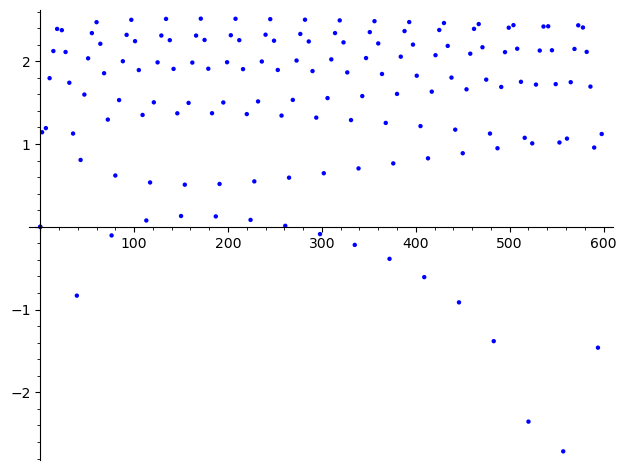

n_list[3:] :
[6, 10, 14, 18, 23, 27, 31, 35, 39, 43, 47, 51, 55, 60, 64, 68, 72, 76, 80, 84, 88, 92, 97, 101, 105, 109, 113, 117, 121, 125, 129, 134, 138, 142, 146, 150, 154, 158, 162, 166, 171, 175, 179, 183, 187, 191, 195, 199, 203, 208, 212, 216, 220, 224, 228, 232, 236, 240, 245, 249, 253, 257, 261, 265, 269, 273, 277, 282, 286, 290, 294, 298, 302, 306, 310, 314, 319, 323, 327, 331, 335, 339, 343, 347, 351, 356, 360, 364, 368, 372, 376, 380, 384, 388, 393, 397, 401, 405, 409, 413, 417, 421, 425, 430, 434, 438, 442, 446, 450, 454, 458, 462, 467, 471, 475, 479, 483, 487, 491, 495, 499, 504, 508, 512, 516, 520, 524, 528, 532, 536, 541, 545, 549, 553, 557, 561, 565, 569, 573, 578, 582, 586, 590, 594, 598]

dt[1:] :
[4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4

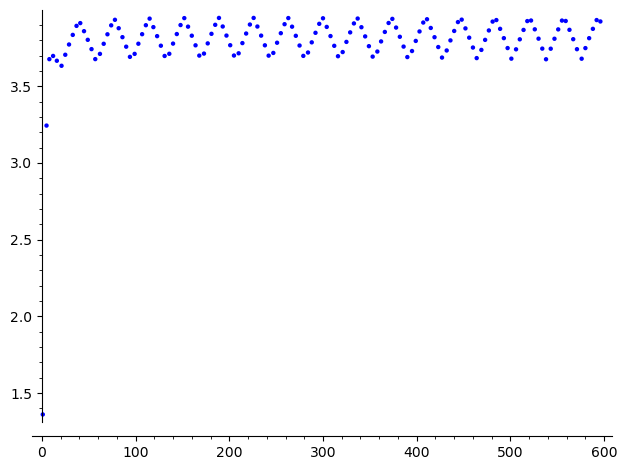

n_list[3:] :
[12, 16, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57, 62, 66, 70, 74, 78, 82, 86, 90, 94, 99, 103, 107, 111, 115, 119, 123, 127, 131, 136, 140, 144, 148, 152, 156, 160, 164, 168, 173, 177, 181, 185, 189, 193, 197, 201, 205, 210, 214, 218, 222, 226, 230, 234, 238, 242, 247, 251, 255, 259, 263, 267, 271, 275, 279, 284, 288, 292, 296, 300, 304, 308, 312, 316, 321, 325, 329, 333, 337, 341, 345, 349, 353, 358, 362, 366, 370, 374, 378, 382, 386, 390, 395, 399, 403, 407, 411, 415, 419, 423, 427, 432, 436, 440, 444, 448, 452, 456, 460, 464, 469, 473, 477, 481, 485, 489, 493, 497, 501, 506, 510, 514, 518, 522, 526, 530, 534, 538, 543, 547, 551, 555, 559, 563, 567, 571, 576, 580, 584, 588, 592, 596]

dt[1:] :
[4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 

In [5]:
def lower_envelope_pairlist(pair_list):
    envelope=[]
    for k in range(0,len(pair_list)-1):
        if k==0:
            val0=pair_list[k][1]
            val1=pair_list[k+1][1]
            if val0<val1:
                envelope.append((k,val0))
        if k==len(pair_list)-1:
            val_end=pair_list[k][1]
            val_preceding=pair_list[k-1][1]
            if val_end<val_preceding:
                envelope.append((k,val_end))
        val_preceding=pair_list[k-1][1]
        val_k=pair_list[k][1]
        val_next=pair_list[k+1][1]
        if val_preceding>val_k:
            if val_next>val_k:
                envelope.append((k,val_k))
    return envelope

def difference_table(lst):
    diffs=[]
    for k in range(0,len(lst)):
        diff=lst[k]-lst[k-1]
        diffs=diffs+[diff]
    return diffs

from sage.all import PolynomialRing, QQ

R = PolynomialRing(QQ, 'x')

def lagrange_poly(points):
    return R.lagrange_polynomial(points)

   
import pickle

with open('/Users/barrybrent/data2/run19jun26no7.txt', 'rb') as rfile:
    log_mins_list = pickle.load(rfile)

print()
print("Analysis of lower envelope of log minimum moduli:")
print()
env=lower_envelope_pairlist(log_mins_list)
pls=list_plot(env)
show(pls)
n_list=[pair[0] for pair in env]
dt=difference_table(n_list)
n_list=[pair[0] for pair in env]
print("n_list[3:] :")
print(n_list[3:])
print()
dt=difference_table(n_list[3:])
print("dt[1:] :")
print(dt[1:])
print()
fives=[]
for k in range(0,len(dt)-1):
    if dt[k]==5:
        fives.append(k)
print("fives:")
print(fives)
print()
nl=n_list[3:len(n_list)-1]
print("nl:",nl)
print()
dtnl=difference_table(nl)
print("dtnl[1:] :")
print(dtnl[1:])
print()
dtnl_2=difference_table(dtnl[1:])
print("dtnl_2:")
print(dtnl_2)
print()
dtnl_3=difference_table(dtnl_2)
print("dtnl_3:")
print(dtnl_3)
print()

def upper_envelope_pairlist(pair_list):
    envelope=[]
    for k in range(0,len(pair_list)-1):
        if k==0:
            val0=pair_list[k][1]
            val1=pair_list[k+1][1]
            if val0>val1:
                envelope.append((k,val0))
        if k==len(pair_list)-1:
            val_end=pair_list[k][1]
            val_preceding=pair_list[k-1][1]
            if val_end>val_preceding:
                envelope.append((k,val_end))
        val_preceding=pair_list[k-1][1]
        val_k=pair_list[k][1]
        val_next=pair_list[k+1][1]
        if val_preceding<val_k:
            if val_next<val_k:
                envelope.append((k,val_k))
    return envelope
print()
print("Analysis of upper envelope of log minimum moduli:")

env=upper_envelope_pairlist(log_mins_list)
pls=list_plot(env)
show(pls)
n_list=[pair[0] for pair in env]
dt=difference_table(n_list)
n_list=[pair[0] for pair in env]
print("n_list[3:] :")
print(n_list[3:])
print()
dt=difference_table(n_list[3:])
print("dt[1:] :")
print(dt[1:])
print()
fives=[]
for k in range(0,len(dt)):
    if dt[k]==5:
        fives.append(k)
print("fives:")
print(fives)
print()


Analysis of lower envelope of minimum moduli:



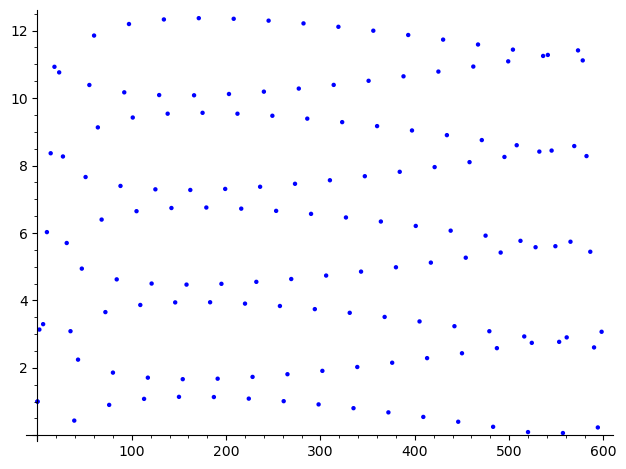

n_list[3:] :
[6, 10, 14, 18, 23, 27, 31, 35, 39, 43, 47, 51, 55, 60, 64, 68, 72, 76, 80, 84, 88, 92, 97, 101, 105, 109, 113, 117, 121, 125, 129, 134, 138, 142, 146, 150, 154, 158, 162, 166, 171, 175, 179, 183, 187, 191, 195, 199, 203, 208, 212, 216, 220, 224, 228, 232, 236, 240, 245, 249, 253, 257, 261, 265, 269, 273, 277, 282, 286, 290, 294, 298, 302, 306, 310, 314, 319, 323, 327, 331, 335, 339, 343, 347, 351, 356, 360, 364, 368, 372, 376, 380, 384, 388, 393, 397, 401, 405, 409, 413, 417, 421, 425, 430, 434, 438, 442, 446, 450, 454, 458, 462, 467, 471, 475, 479, 483, 487, 491, 495, 499, 504, 508, 512, 516, 520, 524, 528, 532, 536, 541, 545, 549, 553, 557, 561, 565, 569, 573, 578, 582, 586, 590, 594, 598]

dt[1:] :
[4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4

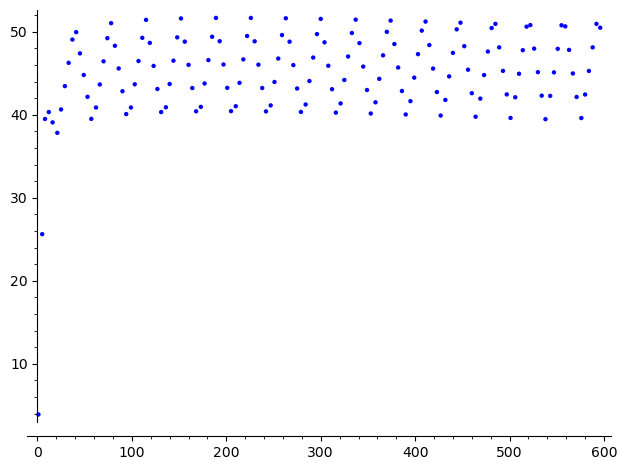

n_list[3:] :
[12, 16, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57, 62, 66, 70, 74, 78, 82, 86, 90, 94, 99, 103, 107, 111, 115, 119, 123, 127, 131, 136, 140, 144, 148, 152, 156, 160, 164, 168, 173, 177, 181, 185, 189, 193, 197, 201, 205, 210, 214, 218, 222, 226, 230, 234, 238, 242, 247, 251, 255, 259, 263, 267, 271, 275, 279, 284, 288, 292, 296, 300, 304, 308, 312, 316, 321, 325, 329, 333, 337, 341, 345, 349, 353, 358, 362, 366, 370, 374, 378, 382, 386, 390, 395, 399, 403, 407, 411, 415, 419, 423, 427, 432, 436, 440, 444, 448, 452, 456, 460, 464, 469, 473, 477, 481, 485, 489, 493, 497, 501, 506, 510, 514, 518, 522, 526, 530, 534, 538, 543, 547, 551, 555, 559, 563, 567, 571, 576, 580, 584, 588, 592, 596]

dt[1:] :
[4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 

In [6]:
#with open('/Users/barrybrent/data2/run16jun26no5.txt', 'wb') as wfile:
#   pickle.dump(mins_list, wfile)
import pickle
with open('/Users/barrybrent/data2/run19jun26no5.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)
def lower_envelope_pairlist(pair_list):
    envelope=[]
    for k in range(0,len(pair_list)-1):
        if k==0:
            val0=pair_list[k][1]
            val1=pair_list[k+1][1]
            if val0<val1:
                envelope.append((k,val0))
        if k==len(pair_list)-1:
            val_end=pair_list[k][1]
            val_preceding=pair_list[k-1][1]
            if val_end<val_preceding:
                envelope.append((k,val_end))
        val_preceding=pair_list[k-1][1]
        val_k=pair_list[k][1]
        val_next=pair_list[k+1][1]
        if val_preceding>val_k:
            if val_next>val_k:
                envelope.append((k,val_k))
    return envelope

def difference_table(lst):
    diffs=[]
    for k in range(0,len(lst)):
        diff=lst[k]-lst[k-1]
        diffs=diffs+[diff]
    return diffs

from sage.all import PolynomialRing, QQ

R = PolynomialRing(QQ, 'x')

def lagrange_poly(points):
    return R.lagrange_polynomial(points)

   

print()
print("Analysis of lower envelope of minimum moduli:")
print()
env=lower_envelope_pairlist(mins_list)
pls=list_plot(env)
show(pls)
n_list=[pair[0] for pair in env]
dt=difference_table(n_list)
n_list=[pair[0] for pair in env]
print("n_list[3:] :")
print(n_list[3:])
print()
dt=difference_table(n_list[3:])
print("dt[1:] :")
print(dt[1:])
print()
fives=[]
for k in range(0,len(dt)-1):
    if dt[k]==5:
        fives.append(k)
print("fives:")
print(fives)
print()
nl=n_list[3:len(n_list)-1]
print("nl:",nl)
print()
dtnl=difference_table(nl)
print("dtnl[1:] :")
print(dtnl[1:])
print()
dtnl_2=difference_table(dtnl[1:])
print("dtnl_2:")
print(dtnl_2)
print()
dtnl_3=difference_table(dtnl_2)
print("dtnl_3:")
print(dtnl_3)
print()

def upper_envelope_pairlist(pair_list):
    envelope=[]
    for k in range(0,len(pair_list)-1):
        if k==0:
            val0=pair_list[k][1]
            val1=pair_list[k+1][1]
            if val0>val1:
                envelope.append((k,val0))
        if k==len(pair_list)-1:
            val_end=pair_list[k][1]
            val_preceding=pair_list[k-1][1]
            if val_end>val_preceding:
                envelope.append((k,val_end))
        val_preceding=pair_list[k-1][1]
        val_k=pair_list[k][1]
        val_next=pair_list[k+1][1]
        if val_preceding<val_k:
            if val_next<val_k:
                envelope.append((k,val_k))
    return envelope
print()
print("Analysis of upper envelope of minimum moduli:")

env=upper_envelope_pairlist(mins_list)
pls=list_plot(env)
show(pls)
n_list=[pair[0] for pair in env]
dt=difference_table(n_list)
n_list=[pair[0] for pair in env]
print("n_list[3:] :")
print(n_list[3:])
print()
dt=difference_table(n_list[3:])
print("dt[1:] :")
print(dt[1:])
print()
fives=[]
for k in range(0,len(dt)):
    if dt[k]==5:
        fives.append(k)
print("fives:")
print(fives)
print()